<a href="https://colab.research.google.com/github/chalevincato-gif/STL10-Classification/blob/main/STL10_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!unzip -q workspace.zip

In [2]:
import torch
print(f"Is CUDA available? {torch.cuda.is_available()}")
print(f"Current device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")


Is CUDA available? True
Current device: Tesla T4


In [19]:
# 1. Point Colab to your source folder
import sys
sys.path.append('/content/src')

# 2. Import your training function
from train import train
import torch

# 3. Execute training AND capture the result in the variable 'trained_model'
print("Starting training in notebook memory...")
trained_model = train()

# 4. Save the weights to a file
torch.save(trained_model.state_dict(), 'baseline_model.pth')
print("Model saved successfully.")

# 5. Download to your local Windows machine
from google.colab import files
files.download('baseline_model.pth')

Starting training in notebook memory...
Executing on: cuda.
Epoch [1/15] | Train Loss: 1.9837 | Val Acc: 31.64%
Epoch [2/15] | Train Loss: 1.7532 | Val Acc: 37.14%
Epoch [3/15] | Train Loss: 1.6778 | Val Acc: 36.79%
Epoch [4/15] | Train Loss: 1.6252 | Val Acc: 40.36%
Epoch [5/15] | Train Loss: 1.5936 | Val Acc: 43.07%
Epoch [6/15] | Train Loss: 1.5635 | Val Acc: 36.64%
Epoch [7/15] | Train Loss: 1.5405 | Val Acc: 36.36%
Epoch [8/15] | Train Loss: 1.5115 | Val Acc: 47.64%
Epoch [9/15] | Train Loss: 1.4836 | Val Acc: 48.57%
Epoch [10/15] | Train Loss: 1.4655 | Val Acc: 45.86%
Epoch [11/15] | Train Loss: 1.4554 | Val Acc: 25.00%
Epoch [12/15] | Train Loss: 1.4359 | Val Acc: 44.64%
Epoch [13/15] | Train Loss: 1.4304 | Val Acc: 41.71%
Epoch [14/15] | Train Loss: 1.4200 | Val Acc: 48.64%
Epoch [15/15] | Train Loss: 1.4006 | Val Acc: 46.43%
Model saved successfully.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [23]:
!python evaluate.py



--- Classification Report ---
              precision    recall  f1-score   support

    airplane       0.72      0.46      0.56       121
        bird       0.69      0.39      0.50       145
         car       0.54      0.86      0.67       160
         cat       0.43      0.36      0.39       145
        deer       0.82      0.09      0.17       149
         dog       0.31      0.15      0.20       134
       horse       0.57      0.69      0.62       150
      monkey       0.27      0.80      0.41       131
        ship       0.76      0.49      0.59       139
       truck       0.49      0.49      0.49       126

    accuracy                           0.48      1400
   macro avg       0.56      0.48      0.46      1400
weighted avg       0.56      0.48      0.46      1400

Figure(1000x800)


In [22]:
import torch
# Check which variable name you used!
try:
    torch.save(trained_model.state_dict(), '/content/baseline_model.pth')
    print("Saved as trained_model")
except NameError:
    torch.save(my_trained_model.state_dict(), '/content/baseline_model.pth')
    print("Saved as my_trained_model")

Saved as trained_model


In [24]:
%%writefile /content/src/train_optimized.py
import torch
import torch.nn as nn
import torch.optim as optim
from dataset import get_dataloaders
from model import SimpleCNN

def train_optimized():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Executing OPTIMIZED SGD Training on: {device}")

    train_loader, val_loader = get_dataloaders('../data')
    model = SimpleCNN().to(device)

    # OPTIMIZATION 1: Weight Initialization (Prevents the model from guessing just one class)
    for m in model.modules():
        if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
            nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')

    criterion = nn.CrossEntropyLoss()

    # OPTIMIZATION 2: SGD with Momentum instead of Adam
    optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9, weight_decay=1e-4)

    epochs = 15
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {train_loss/len(train_loader):.4f} | Val Acc: {100*correct/total:.2f}%")

    # Save the new weights with a NEW name so we don't overwrite the baseline
    torch.save(model.state_dict(), '../optimized_model.pth')
    print("Optimized Model Saved to /content/optimized_model.pth!")

if __name__ == "__main__":
    train_optimized()

Writing /content/src/train_optimized.py


In [25]:
!python train_optimized.py


Executing OPTIMIZED SGD Training on: cuda
Epoch [1/15] | Train Loss: 2.9953 | Val Acc: 30.00%
Epoch [2/15] | Train Loss: 2.3294 | Val Acc: 34.36%
Epoch [3/15] | Train Loss: 2.1694 | Val Acc: 36.36%
Epoch [4/15] | Train Loss: 2.0446 | Val Acc: 37.29%
Epoch [5/15] | Train Loss: 1.9701 | Val Acc: 37.93%
Epoch [6/15] | Train Loss: 1.9380 | Val Acc: 41.36%
Epoch [7/15] | Train Loss: 1.8850 | Val Acc: 35.21%
Epoch [8/15] | Train Loss: 1.8617 | Val Acc: 42.86%
Epoch [9/15] | Train Loss: 1.8492 | Val Acc: 31.14%
Epoch [10/15] | Train Loss: 1.8105 | Val Acc: 39.36%
Epoch [11/15] | Train Loss: 1.8040 | Val Acc: 45.50%
Epoch [12/15] | Train Loss: 1.7577 | Val Acc: 41.14%
Epoch [13/15] | Train Loss: 1.7522 | Val Acc: 42.79%
Epoch [14/15] | Train Loss: 1.7521 | Val Acc: 45.07%
Epoch [15/15] | Train Loss: 1.7323 | Val Acc: 43.29%
Optimized Model Saved to /content/optimized_model.pth!


In [26]:
%%writefile /content/src/evaluate_optimized.py
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from dataset import get_dataloaders
from model import SimpleCNN

def evaluate_optimized():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Load Data
    _, test_loader = get_dataloaders('../data', batch_size=32)

    # Setup Model and Load OPTIMIZED weights
    model = SimpleCNN().to(device)
    model.load_state_dict(torch.load('../optimized_model.pth'))
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Generate Metrics
    classes = ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']
    print("\n--- OPTIMIZED Classification Report ---")
    print(classification_report(all_labels, all_preds, target_names=classes))

    # Save and Show Confusion Matrix (Using Green to distinguish from the Baseline Blue)
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap='Greens')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix - Optimized Model (SGD)')

    plt.savefig('../confusion_matrix_optimized.png', dpi=300)
    plt.show()

if __name__ == "__main__":
    evaluate_optimized()

Writing /content/src/evaluate_optimized.py


In [27]:
!python evaluate_optimized.py



--- OPTIMIZED Classification Report ---
              precision    recall  f1-score   support

    airplane       0.51      0.82      0.63       123
        bird       0.31      0.58      0.41       133
         car       0.52      0.77      0.62       133
         cat       0.28      0.37      0.32       140
        deer       0.31      0.32      0.32       145
         dog       0.38      0.32      0.35       158
       horse       0.55      0.34      0.42       151
      monkey       0.37      0.30      0.33       133
        ship       0.80      0.29      0.43       138
       truck       0.88      0.19      0.31       146

    accuracy                           0.42      1400
   macro avg       0.49      0.43      0.41      1400
weighted avg       0.49      0.42      0.41      1400

Figure(1000x800)


In [9]:
!pip install ttach grad-cam


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 60.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=e7395546adafa2aceb5d8e15017b70c54e66242152e7c7d36683b2b549d869c2
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [30]:
%%writefile /content/src/run_gradcam.py
import torch
import numpy as np
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image # Fixed import
from dataset import get_dataloaders
from model import SimpleCNN

def generate_cam():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Running Grad-CAM on: {device}")

    model = SimpleCNN().to(device)
    model.load_state_dict(torch.load('../baseline_model.pth'))
    model.eval()

    target_layers = [model.bn3]

    _, test_loader = get_dataloaders('../data', batch_size=1)
    input_tensor, label = next(iter(test_loader))
    input_tensor = input_tensor.to(device)

    cam = GradCAM(model=model, target_layers=target_layers)
    targets = [ClassifierOutputTarget(label.item())]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]

    img_np = input_tensor.squeeze().cpu().numpy().transpose(1, 2, 0)
    # Ensure image is in [0, 1] range for the library
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-7)

    # Use the updated function name here
    visualization = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

    classes = ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']
    plt.figure(figsize=(6, 6))
    plt.imshow(visualization)
    plt.title(f"Grad-CAM Heatmap (Actual Class: {classes[label.item()]})")
    plt.axis('off')

    plt.savefig('../grad_cam_result.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("Grad-CAM successfully saved to /content/grad_cam_result.png")

if __name__ == "__main__":
    generate_cam()

Overwriting /content/src/run_gradcam.py


In [31]:
!python run_gradcam.py

Running Grad-CAM on: cuda
Figure(600x600)
Grad-CAM successfully saved to /content/grad_cam_result.png


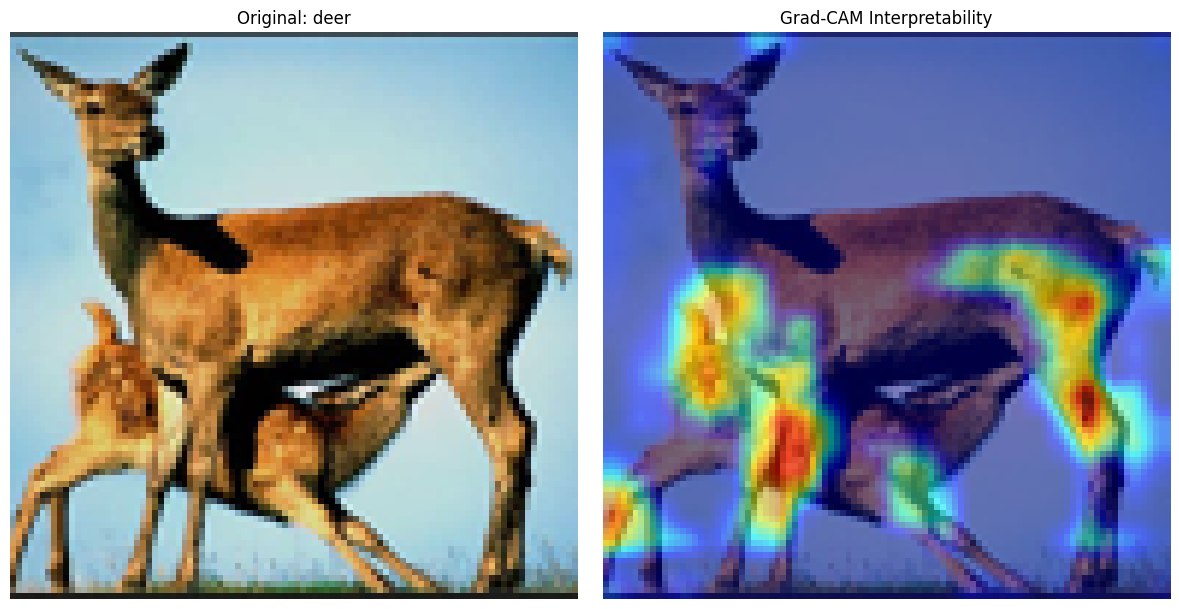

In [33]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
from dataset import get_dataloaders
from model import SimpleCNN

# 1. Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleCNN().to(device)
model.load_state_dict(torch.load('/content/baseline_model.pth'))
model.eval()

# 2. Get Data
_, test_loader = get_dataloaders('/content/data', batch_size=1)
input_tensor, label = next(iter(test_loader))
input_tensor = input_tensor.to(device)

# 3. Generate Grad-CAM
target_layers = [model.bn3]
cam = GradCAM(model=model, target_layers=target_layers)
targets = [ClassifierOutputTarget(label.item())]
grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]

# 4. Process Images for Display
img_np = input_tensor.squeeze().cpu().numpy().transpose(1, 2, 0)
img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-7)
visualization = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

# 5. Plotting Side-by-Side
classes = ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']
plt.figure(figsize=(12, 6))

# Left: Original
plt.subplot(1, 2, 1)
plt.imshow(img_np)
plt.title(f"Original: {classes[label.item()]}")
plt.axis('off')

# Right: Heatmap
plt.subplot(1, 2, 2)
plt.imshow(visualization)
plt.title("Grad-CAM Interpretability")
plt.axis('off')

plt.tight_layout()
plt.show()

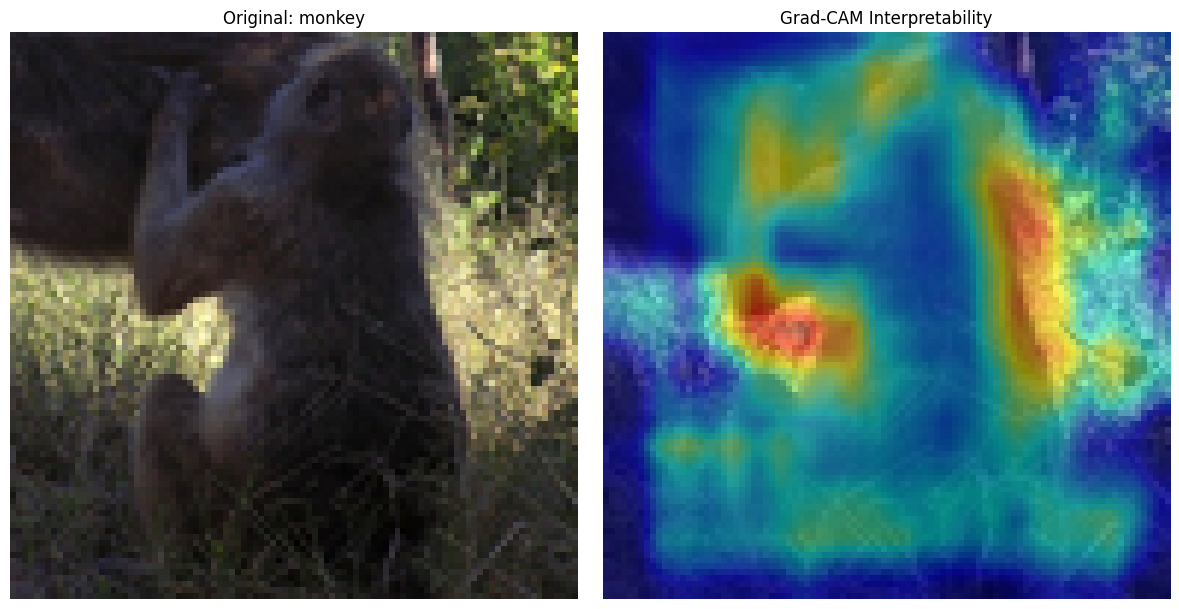

In [34]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
from dataset import get_dataloaders
from model import SimpleCNN

# 1. Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleCNN().to(device)
model.load_state_dict(torch.load('/content/baseline_model.pth'))
model.eval()

# 2. Get Data
_, test_loader = get_dataloaders('/content/data', batch_size=1)
input_tensor, label = next(iter(test_loader))
input_tensor = input_tensor.to(device)

# 3. Generate Grad-CAM
target_layers = [model.bn3]
cam = GradCAM(model=model, target_layers=target_layers)
targets = [ClassifierOutputTarget(label.item())]
grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]

# 4. Process Images for Display
img_np = input_tensor.squeeze().cpu().numpy().transpose(1, 2, 0)
img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-7)
visualization = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

# 5. Plotting Side-by-Side
classes = ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']
plt.figure(figsize=(12, 6))

# Left: Original
plt.subplot(1, 2, 1)
plt.imshow(img_np)
plt.title(f"Original: {classes[label.item()]}")
plt.axis('off')

# Right: Heatmap
plt.subplot(1, 2, 2)
plt.imshow(visualization)
plt.title("Grad-CAM Interpretability")
plt.axis('off')

plt.tight_layout()
plt.show()